# **Nearest Neighbour (NN) comparison between 3D and its 2D projection as a function of SDR (Spatial Dynamic Range - i.e. smoothing).**

- Generates N random points uniformly within a 3D sphere (radius R).
- Optionally rotates the cloud (Euler angles) before projection.
- Projects to 2D by dropping the z-axis.
- Removes points closer than smoothing length as defined by SDR.
- Computes NN in 3D and 2D.
- Compares edge sets and lengths; reports overlap metrics.
- Plots the 3D NN (perspective) and the 2D NN, and the histogram. 

Produces the following from Barnes et al. (2026): 

- **Fig 4**: Illustration of the impact of finite spatial dynamic range on nearest–neighbour (NN) statistics, using a uniform distribution of N = 200
points within a sphere of radius R = 1.0. Left: intrinsic 3D NN graph. Middle: its 2D projection after applying a beam–blending step that merges
points closer than one beam width, corresponding here to a spatial dynamic range SDR = FoV/FWHMbeam = 10. Circles mark the original
2D positions (open) and the resulting beam–blended centroids (filled). Right: distributions of NN edge lengths in 3D and 2D after blending. In
this example, 135 of the 200 projected cores (67.5%) are merged into 65 effective groups, erasing all topological correspondence between the
intrinsic and projected networks (J = 0.00, overlap fraction = 0). The typical 3D and 2D NN lengths become nearly equal (⟨ℓ3D⟩/⟨ℓ2D⟩ ≃ 1.0), as
beam blending suppresses the shortest intrinsic separations that normally produce the geometric compression factor (4/π ≃ 1.27). This example
illustrates that limited spatial resolution can strongly distort the apparent connectivity and scale distribution of dense cores even in an intrinsically
uniform configuration

In [ ]:
# Core scientific imports
import numpy as np
import matplotlib.pyplot as plt

# corespaceing3d imports
from corespaceing3d import main
from corespaceing3d.plotting import plot_3d, plot_2d, plot_length_histograms

In [2]:
# ------------------------- configuration -------------------------
N_POINTS = 200       # number of cores
RADIUS = 1.0         # sphere radius
SEED = 42            # RNG seed for reproducibility

# Rotation of the 3D clump *before* projecting to 2D
# (Right-handed, extrinsic rotations; order Z (alpha), Y (beta), X (gamma))
ALPHA_DEG = 0     # rotate about Z
BETA_DEG  = 0     # rotate about Y
GAMMA_DEG = 0     # rotate about X

# Toggle plotting
SHOW_PLOTS = True
# -----------------------------------------------------------------

[Beam blending (FoF)] dyn_range=10.0, res=0.1000 → merged 135/200 (67.5%) cores into 65 groups
After beam blending: 65 points remain (merged 135)

NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  uniform (Uniform)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 0 / 199
Only in 3D:  139
Only in 2D:  47
Overlap (3D→2D recovery): 0.000
Jaccard similarity:        0.000

Total NN length
------------------------------------------------------------------------
3D: 24.42287
2D: 8.14161

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.986  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=139):
  mean=0.17570, median=0.17903, std=0.06186, mad=0.04557
  min=0.04724, p10=0.09221, p25=0.12570, p50=0.17903, p75=0.21993, p90=0.24927, p95=0.27941, p99=0.30817, max=0.32680

2D NN edge-length stats (N=47):

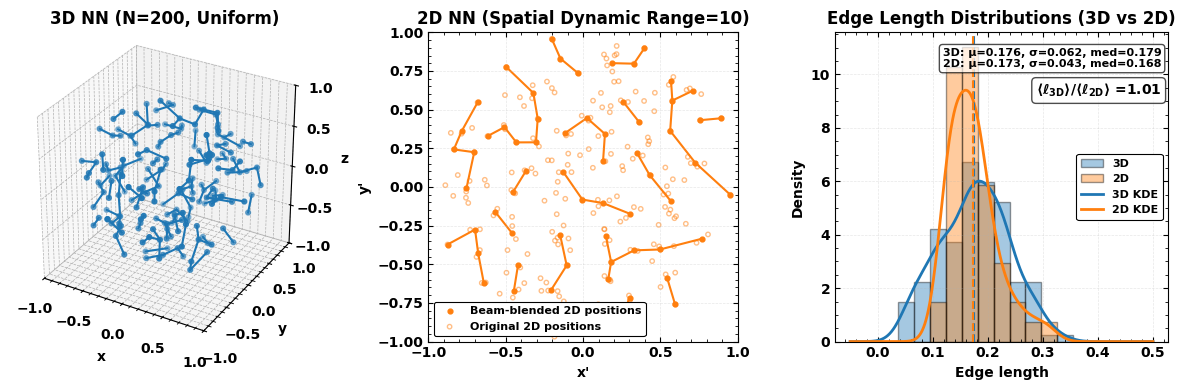

In [3]:
# Run the pipeline
profile = "uniform"
dyn_range = 10.0

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    profile_kwargs={"dyn_range": dyn_range},               # e.g. {'p':-2.0} for powerlaw
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot   = out["pts3d_rot"]
pts2d       = out["pts2d"]
pts2d_blend = out["pts2d_blend"]
edges3d     = out["edges3d"]
edges2d     = out["edges2d"]
len3        = out["len3"]
len2        = out["len2"]
title3d     = out["titles"]["title3d"]
# title2d     = out["titles"]["title2d"]
title2d     =  f"2D NN (Spatial Dynamic Range={dyn_range:.0f})"


# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
ax_2d = plot_2d(ax2d, pts2d_blend, edges2d, title=title2d)
ax_2d.scatter([], [], c="C1", s=12, label="Beam-blended 2D positions")
ax_2d.scatter(pts2d[:,0], pts2d[:,1], ec="C1", fc='none', alpha=0.5, s=10, label="Original 2D positions")
leg = ax_2d.legend(prop={'size': 8}, facecolor='white', framealpha=1, loc="lower left")
leg.set_zorder(20)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(0.8)

bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}_DynRange{dyn_range:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)